#### Hybrid Simulation Using PySD and Parallel Programming

In [2]:
import psutil
import pysd
import pandas as pd
from joblib import Parallel, delayed

In [3]:
# identify the number of physical cores
print("Number of Physical Cores: ", psutil.cpu_count(logical=False))

Number of Physical Cores:  4


In [4]:
# 1. PRE-TRANSLATE (Done once by the main process)
# This creates the .py file version of your model so workers don't have to
model_filename = "Glossi v2.mdl"
py_model_file = pysd.read_vensim(model_filename)
# Get the path of the generated python file
py_path = py_model_file.py_model_file

#### Define a parallelable function

In [5]:
def run_single_simulation(seed) -> pd.DataFrame:
    """
    Each CPU core will now execute this function, load its own 
    copy of the model, run it, and then clear it from memory.
    """
    # Load the model INSIDE the function so it stays on this core
    local_model = pysd.load(py_path)
    
    # Run the simulation with the specific seed
    result = local_model.run(params={'Model Seed': seed})
    
    return result['Dryness Level']

#### Setting number of runs

In [6]:
# set number of samples and seeds
num_samples = 10000
seeds = range(num_samples)

#### Parallelizing the simulation

In [ ]:
print(f"Starting {num_samples} parallel runs...")

list_of_results = Parallel(n_jobs=-1)(
    delayed(run_single_simulation)(seed) for seed in seeds
)

print(f"Completed {num_samples} runs.")

Starting 10000 parallel runs...


#### Combine results in a master DataFrame

In [ ]:
# Create a list of column names like ["run_0", "run_1", ..., "run_9999"]
column_names = [f"run_{s}" for s in seeds]

all_runs_df = pd.concat(list_of_results, axis=1)

all_runs_df.index.name = "Time"

print("ALL simulations complete.")
print(all_runs_df.head())

In [11]:
# Save results to a CSV file
all_runs_df.to_csv("glossi_parallel_results.csv")

In [48]:
# Determine confidence interval
import numpy as np

mean_dryness = all_runs_df.mean(axis=1)
std_dryness = all_runs_df.std(axis=1)
n = all_runs_df.shape[1]  # number of runs

""" Calculate the 99% Confidence Interval (using Z = 2.576)
This formula identifies the 'precision' or margin of error """
precision = 2.576 * (std_dryness / np.sqrt(n))

ci_upper = mean_dryness + precision
ci_lower = mean_dryness - precision

#### Plotting the Confidence Interval

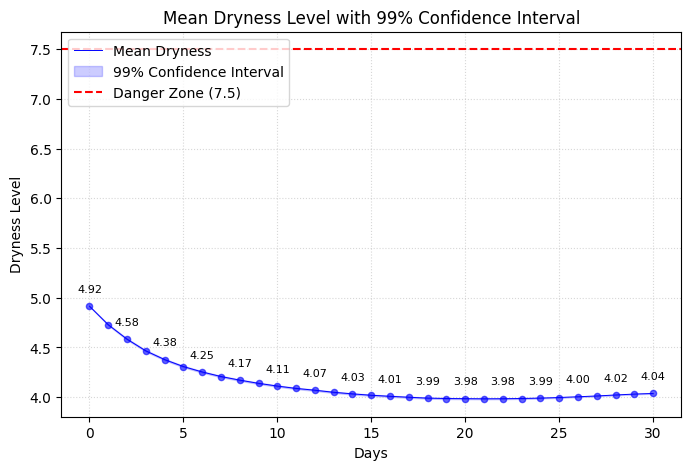

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# plotting the regression line
plt.plot(
    mean_dryness.index, 
    mean_dryness, 
    label="Mean Dryness", 
    color="blue", 
    linewidth=0.7
)

# determining the points to plot
plt.scatter(
    mean_dryness.index, 
    mean_dryness, 
    color="blue", 
    s=20, 
    zorder=3,
    alpha=0.6,
)

# OPTIONAL: Add text labels for each point
for i, txt in enumerate(mean_dryness):
    if i % 2 == 0: # Only label every 2nd day to keep it clean
        plt.annotate(f"{txt:.2f}", (mean_dryness.index[i], mean_dryness.values[i]), 
                            textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.fill_between(
    mean_dryness.index,
    ci_lower,
    ci_upper,
    color="blue",
    alpha=0.2,
    label="99% Confidence Interval"
)

# add threshold line
plt.axhline(
    y=7.5,
    color="red",
    linestyle="--",
    label="Danger Zone (7.5)"
)

#labeling the graph
plt.title("Mean Dryness Level with 99% Confidence Interval")
plt.xlabel("Days")
plt.ylabel("Dryness Level")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)

plt.show()


### 💡Key Takeaways

Based on the plot, the Stochastic SD model proves to be a highly stable representation of MY hair factors. By parallelizing the sampling of over a thousand runs, it effectively eliminated the noise of human factors and identified a reliable mean value. Additionally, the 99% confidence level still resulted in a tight confidence interval, presenting the model as a high-fidelity decision support system.